### Import Libraries and Functions

In [25]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import textwrap

root_dir = Path("../../..").resolve()
src_dir = root_dir / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from hybridsim import results as res

In [26]:
exp_dir = Path("../outputs")
raw_dir = exp_dir / "raw"
summary_dir = exp_dir / "summary_tables"
plot_dir = exp_dir / "plots"

plot_dir.mkdir(parents=True, exist_ok=True)

In [27]:
scenario = "weighted_equal"

experiment_names = [
    "stock_proportional_weighted_equal",
    "boundary_shift_weighted_equal",
]

array_filenames = [
    f"sd_arrays_{experiment_name}.npz"
    for experiment_name in experiment_names
]

scenario_metadata_filenames = [
    f"scenario_metadata_{experiment_name}.csv"
    for experiment_name in experiment_names
]

scenario_comparison_filename = (
    f"scenario_level_summary_{scenario}.csv"
)
referral_summary_filename = (
    f"referral_summary_{scenario}.csv"
)

### Load results

In [28]:
arrays_list = [
    np.load(
        raw_dir / array_filename,
        allow_pickle=True,
    )
    for array_filename in array_filenames
]

scenario_metadata_list = [
    pd.read_csv(
        raw_dir / scenario_metadata_filename
    )
    for scenario_metadata_filename
    in scenario_metadata_filenames
]

for metadata in scenario_metadata_list:
    if "scenario_index" in metadata.columns:
        metadata.sort_values(
            "scenario_index",
            inplace=True,
        )
        metadata.reset_index(
            drop=True,
            inplace=True,
        )

    if (
        "stock_proportional_mean_time_days"
        not in metadata.columns
    ):
        metadata[
            "stock_proportional_mean_time_days"
        ] = np.nan

    if (
        "boundary_shift_proportion"
        not in metadata.columns
    ):
        metadata[
            "boundary_shift_proportion"
        ] = np.nan

t = arrays_list[0]["t"]
severity_levels = list(
    arrays_list[0]["severity_levels"]
)

for arrays in arrays_list[1:]:
    if not np.array_equal(t, arrays["t"]):
        raise ValueError(
            "The experiments use different time grids."
        )

    if (
        severity_levels
        != list(arrays["severity_levels"])
    ):
        raise ValueError(
            "The experiments use different severity levels."
        )

stocks_array = np.concatenate(
    [
        arrays["stocks"]
        for arrays in arrays_list
    ],
    axis=0,
)

lambdas_array = np.concatenate(
    [
        arrays["lambdas"]
        for arrays in arrays_list
    ],
    axis=0,
)

scenario_names = [
    scenario_name
    for arrays in arrays_list
    for scenario_name in arrays["scenario_names"]
]

low_idx = severity_levels.index("low")
medium_idx = severity_levels.index("medium")
high_idx = severity_levels.index("high")

scenario_metadata = pd.concat(
    scenario_metadata_list,
    ignore_index=True,
)

scenario_comparison = pd.read_csv(
    summary_dir / scenario_comparison_filename
)
referral_summary = pd.read_csv(
    summary_dir / referral_summary_filename
)

scenario_lookup = {
    scenario_name: idx
    for idx, scenario_name in enumerate(
        scenario_metadata["scenario"]
    )
}

scenario_metadata.head()

,scenario_index,scenario,deterioration_model,deterioration_label,stock_proportional_mean_time_days,boundary_shift_proportion,gatekeeping_policy,description
0,0,stock_proportional_six_months_weighted_equal,stock_proportional,six_months,180.0,NaN,weighted_equal,Stock proportional deterioration: six_months; ...
1,1,stock_proportional_two_years_weighted_equal,stock_proportional,two_years,730.0,NaN,weighted_equal,Stock proportional deterioration: two_years; g...
2,2,stock_proportional_five_years_weighted_equal,stock_proportional,five_years,1825.0,NaN,weighted_equal,Stock proportional deterioration: five_years; ...
3,3,stock_proportional_ten_years_weighted_equal,stock_proportional,ten_years,3650.0,NaN,weighted_equal,Stock proportional deterioration: ten_years; g...
4,0,boundary_shift_0_01_weighted_equal,boundary_shift,shift_0.01,NaN,0.01,weighted_equal,Boundary shift deterioration: 0.01 shift per s...


### Plotting Functions

In [29]:
def get_scenario_arrays(
    scenario,
    stocks_array,
    lambdas_array,
    scenario_metadata,
    scenario_column="scenario",
):
    """Return stock and referral arrays for one named scenario."""
    if scenario_column not in scenario_metadata.columns:
        raise ValueError(
            f"scenario_metadata must contain a '{scenario_column}' column."
        )

    matching_rows = scenario_metadata.index[
        scenario_metadata[scenario_column] == scenario
    ].tolist()

    if len(matching_rows) == 0:
        raise ValueError(f"Scenario not found: {scenario}")

    if len(matching_rows) > 1:
        raise ValueError(f"Scenario name is not unique: {scenario}")

    scenario_idx = scenario_metadata.index.get_loc(matching_rows[0])
    scenario_row = scenario_metadata.iloc[scenario_idx]

    stocks = [
        stocks_array[scenario_idx, :, 0],
        stocks_array[scenario_idx, :, 1],
        stocks_array[scenario_idx, :, 2],
    ]

    referral_numbers = [
        lambdas_array[scenario_idx, :, 0],
        lambdas_array[scenario_idx, :, 1],
        lambdas_array[scenario_idx, :, 2],
    ]

    return scenario_row, stocks, referral_numbers

In [30]:
def plot_referral_numbers_over_time_grid(
    selected_scenarios,
    scenario_lookup,
    stocks_array,
    lambdas_array,
    scenario_metadata,
    t,
    nrows=2,
    ncols=2,
    figsize=(5 * 2, 4 * 2),
    subtitle_width=35,
    ylim=None,
    title="Referral Numbers Over Time",
    filename=None,
    show=True,
):
    t_years = np.asarray(t) / 365.25

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).flatten()

    colors = ["#D81B60", "#1E88E5", "#FFC107"]
    labels = [
        "$\\Lambda_1(t)$ (Low)",
        "$\\Lambda_2(t)$ (Medium)",
        "$\\Lambda_3(t)$ (High)",
    ]

    legend_handles = None
    legend_labels = None

    for ax, scenario in zip(axes, selected_scenarios):
        if scenario not in scenario_lookup:
            ax.set_visible(False)
            continue

        scenario_row, stocks, referral_numbers = get_scenario_arrays(
            scenario,
            stocks_array,
            lambdas_array,
            scenario_metadata,
        )
        description = scenario_row["description"]

        referrals = np.asarray(referral_numbers, dtype=float)

        low_referrals = referrals[low_idx]
        medium_referrals = referrals[medium_idx]
        high_referrals = referrals[high_idx]

        ax.plot(
            t_years,
            low_referrals,
            color=colors[0],
            label=labels[0],
        )
        ax.plot(
            t_years,
            medium_referrals,
            color=colors[1],
            label=labels[1],
        )
        ax.plot(
            t_years,
            high_referrals,
            color=colors[2],
            label=labels[2],
        )

        ax.set_title(
            textwrap.fill(description, width=subtitle_width),
            fontsize=11,
        )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.grid(
            True,
            which="both",
            linestyle="--",
            linewidth=0.5,
            color="gray",
        )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for ax in axes[len(selected_scenarios):]:
        ax.set_visible(False)

    axes_grid = np.asarray(axes).reshape(nrows, ncols)

    for col in range(ncols):
        visible_axes_in_col = [
            axes_grid[row, col]
            for row in range(nrows)
            if axes_grid[row, col].get_visible()
        ]

        if visible_axes_in_col:
            bottom_visible_ax = visible_axes_in_col[-1]
            bottom_visible_ax.tick_params(labelbottom=True)
            bottom_visible_ax.xaxis.set_tick_params(
                which="both",
                labelbottom=True,
            )

    fig.suptitle(title, fontsize=18, y=0.975)
    fig.supxlabel("Time (years)", fontsize=14, y=0.06)
    fig.supylabel("Number of Referrals", fontsize=14, x=0.04)

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.95),
            ncol=3,
            fontsize=12,
            frameon=False,
        )

    fig.tight_layout(rect=[0.02, 0.03, 1, 0.96])

    if filename:
        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight",
            transparent=True,
        )

    if show:
        plt.show()

    return fig, axes

In [31]:
def plot_referral_case_mix_over_time_grid(
    selected_scenarios,
    scenario_lookup,
    stocks_array,
    lambdas_array,
    scenario_metadata,
    t,
    nrows=2,
    ncols=2,
    figsize=(5 * 2, 4 * 2),
    subtitle_width=35,
    ylim=(0, 1),
    title="Referral Case Mix Over Time",
    filename=None,
    show=True,
):
    t_years = np.asarray(t) / 365.25

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).flatten()
    colors = ["#D81B60", "#1E88E5", "#FFC107"]
    labels = [
        "$\\Lambda_1(t)$ (Low)",
        "$\\Lambda_2(t)$ (Medium)",
        "$\\Lambda_3(t)$ (High)",
    ]

    legend_handles = None
    legend_labels = None

    for ax, scenario in zip(axes, selected_scenarios):
        if scenario not in scenario_lookup:
            ax.set_visible(False)
            continue

        scenario_row, stocks, referral_numbers = get_scenario_arrays(scenario, stocks_array, lambdas_array, scenario_metadata)
        description = scenario_row["description"]
        referrals = np.asarray(referral_numbers, dtype=float)
        total_referrals = referrals.sum(axis=0)
        referral_proportions = np.divide(
            referrals,
            total_referrals,
            out=np.zeros_like(referrals),
            where=total_referrals > 0,
        )

        low_referrals = referral_proportions[low_idx]
        medium_referrals = referral_proportions[medium_idx]
        high_referrals = referral_proportions[high_idx]

        ax.fill_between(
            t_years,
            high_referrals,
            0,
            color=colors[2],
            label=labels[2],
        )
        ax.fill_between(
            t_years,
            high_referrals + medium_referrals,
            high_referrals,
            color=colors[1],
            label=labels[1],
        )
        ax.fill_between(
            t_years,
            high_referrals + medium_referrals + low_referrals,
            high_referrals + medium_referrals,
            color=colors[0],
            label=labels[0],
        )

        ax.set_title(textwrap.fill(description, width=subtitle_width), fontsize=11)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.grid(
            True,
            which="both",
            linestyle="--",
            linewidth=0.5,
            color="gray",
        )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for ax in axes[len(selected_scenarios):]:
        ax.set_visible(False)

    axes_grid = np.asarray(axes).reshape(nrows, ncols)

    for col in range(ncols):
        visible_axes_in_col = [
            axes_grid[row, col]
            for row in range(nrows)
            if axes_grid[row, col].get_visible()
        ]

        if visible_axes_in_col:
            bottom_visible_ax = visible_axes_in_col[-1]
            bottom_visible_ax.tick_params(labelbottom=True)
            bottom_visible_ax.xaxis.set_tick_params(which="both", labelbottom=True)

    fig.suptitle(title, fontsize=18, y=0.975)
    fig.supxlabel("Time (years)", fontsize=14, y=0.06)
    fig.supylabel("Proportion of Referrals", fontsize=14, x=0.04)

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.95),
            ncol=3,
            fontsize=12,
            frameon=False,
        )

    fig.tight_layout(rect=[0.02, 0.03, 1, 0.96])

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight", transparent=True)

    if show:
        plt.show()

    return fig, axes

In [32]:
def plot_stacked_stocks_over_time_grid(
    selected_scenarios,
    stocks_array,
    lambdas_array,
    scenario_metadata,
    t,
    nrows=2,
    ncols=2,
    figsize=(5 * 2, 4 * 2),
    subtitle_width=35,
    ylim=None,
    title="Stacked Stock Sizes Over Time",
    filename=None,
    show=True,
):
    t_years = np.asarray(t) / 365.25
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).flatten()

    colors = ["#D81B60", "#1E88E5", "#FFC107"]
    labels = [
        "$P_1(t)$ (Low)",
        "$P_2(t)$ (Medium)",
        "$P_3(t)$ (High)",
    ]

    legend_handles = None
    legend_labels = None

    for ax, scenario in zip(axes, selected_scenarios):
        scenario_row, stocks, referral_numbers = get_scenario_arrays(scenario, stocks_array, lambdas_array, scenario_metadata)
        description = scenario_row["description"]

        stocks = np.asarray(stocks, dtype=float)

        P0 = stocks[0]
        P1 = stocks[1]
        P2 = stocks[2]

        ax.fill_between(
            t_years,
            P2,
            0,
            color=colors[2],
            label=labels[2],
        )
        ax.fill_between(
            t_years,
            P2 + P1,
            P2,
            color=colors[1],
            label=labels[1],
        )
        ax.fill_between(
            t_years,
            P2 + P1 + P0,
            P2 + P1,
            color=colors[0],
            label=labels[0],
        )

        ax.set_title(textwrap.fill(description, width=subtitle_width), fontsize=11)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.grid(
            True,
            which="both",
            linestyle="--",
            linewidth=0.5,
            color="gray",
        )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for ax in axes[len(selected_scenarios):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=18, y=0.975)
    fig.supxlabel("Time (years)", fontsize=14, y=0.06)
    fig.supylabel("Stock Size", fontsize=14, x=0.04)

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.95),
            ncol=3,
            fontsize=12,
            frameon=False,
        )

    fig.tight_layout(rect=[0.02, 0.03, 1, 0.96])

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight", transparent=True)

    if show:
        plt.show()

    return fig, axes

### Plot Boundary Shift Deterioration Results

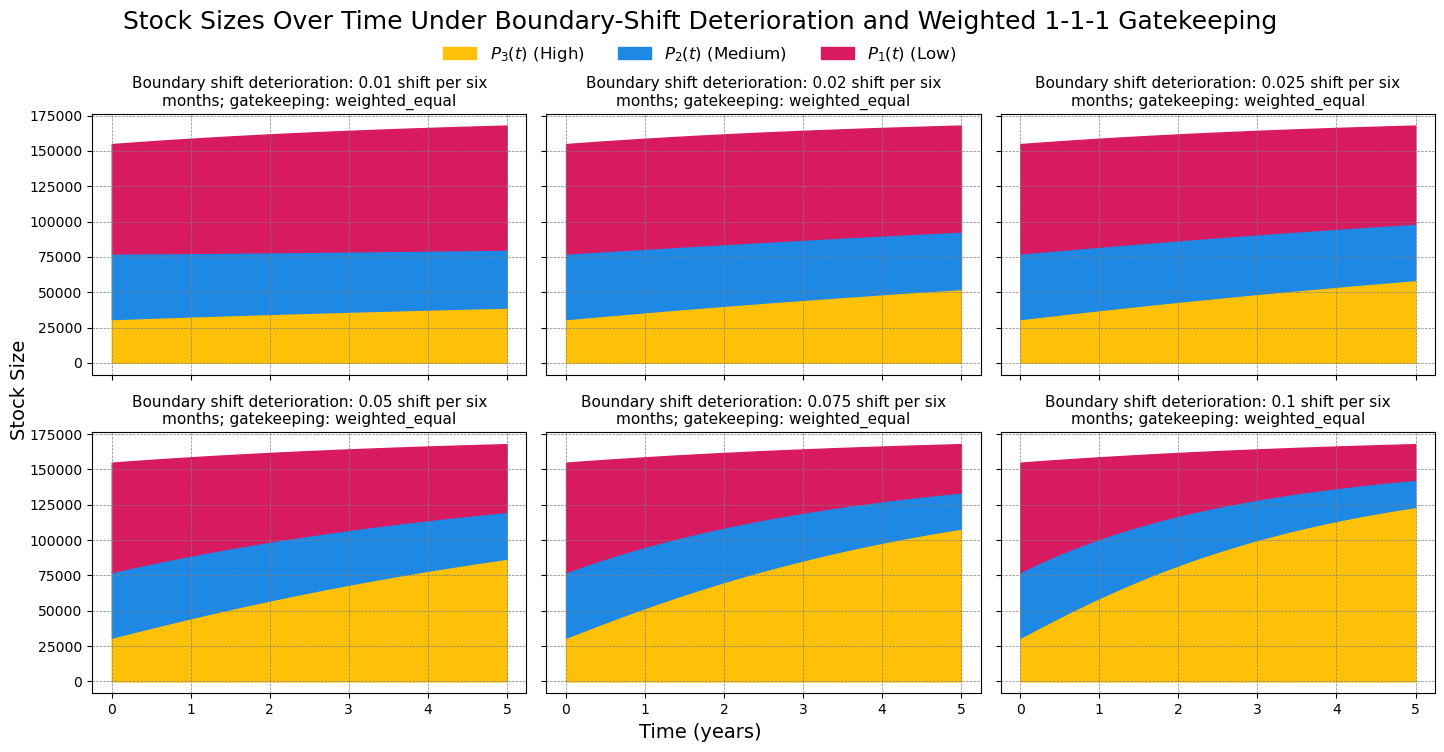

In [33]:
selected_scenarios = (
    scenario_metadata.loc[
        scenario_metadata["deterioration_model"]
        == "boundary_shift",
        "scenario",
    ]
    .tolist()
)

filename = (
    plot_dir
    / "boundary_shift_stocks.pdf"
)

fig, axes = plot_stacked_stocks_over_time_grid(
    selected_scenarios=selected_scenarios,
    stocks_array=stocks_array,
    lambdas_array=lambdas_array,
    scenario_metadata=scenario_metadata,
    t=t,
    nrows=2,
    ncols=3,
    figsize=(15, 8),
    subtitle_width=50,
    title=(
        "Stock Sizes Over Time Under "
        "Boundary-Shift Deterioration "
        "and Weighted 1-1-1 Gatekeeping"
    ),
    filename=filename,
    show=True,
)

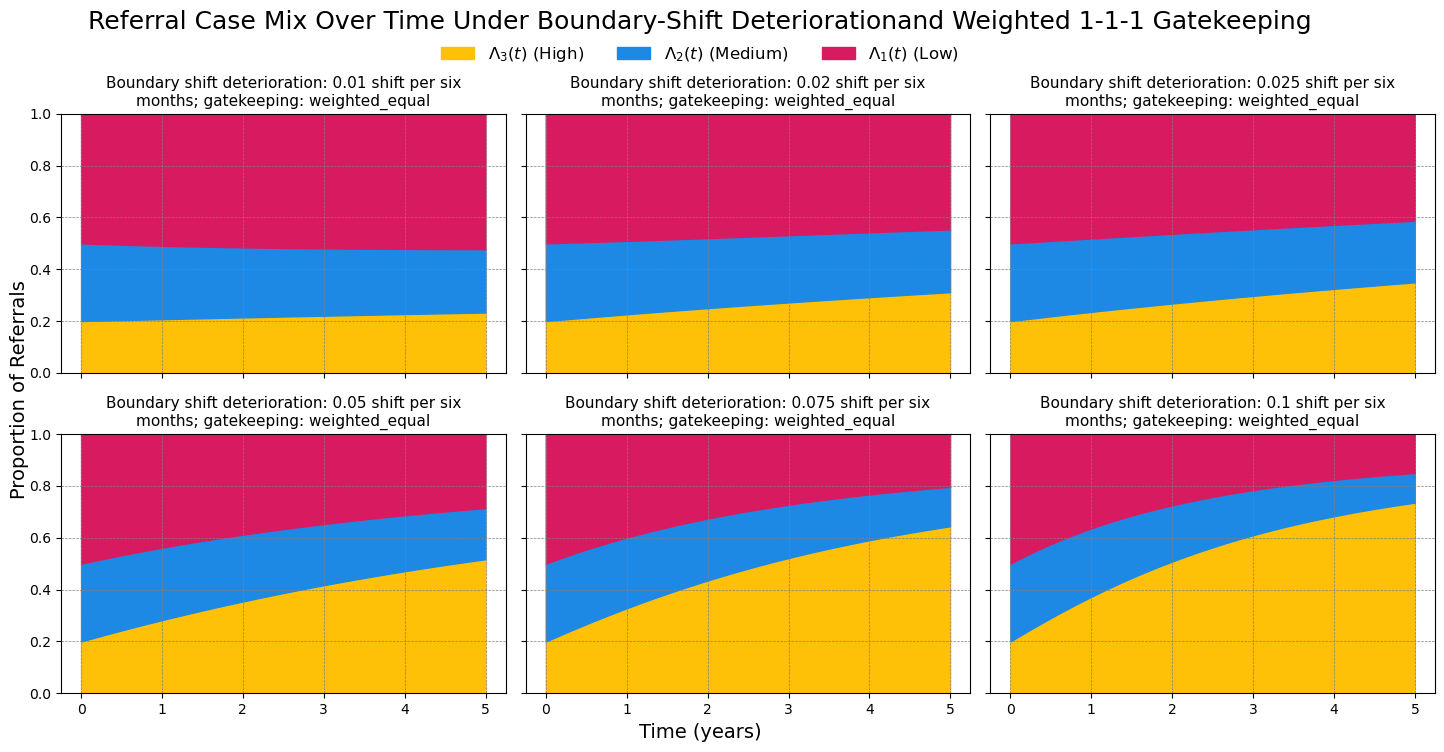

In [34]:
selected_scenarios = (
    scenario_metadata.loc[
        scenario_metadata["deterioration_model"]
        == "boundary_shift",
        "scenario",
    ]
    .tolist()
)

filename = (
    plot_dir
    / "boundary_shift_referral_case_mix.pdf"
)

fig, axes = plot_referral_case_mix_over_time_grid(
    selected_scenarios=selected_scenarios,
    scenario_lookup=scenario_lookup,
    stocks_array=stocks_array,
    lambdas_array=lambdas_array,
    scenario_metadata=scenario_metadata,
    t=t,
    nrows=2,
    ncols=3,
    figsize=(15, 8),
    subtitle_width=50,
    title=(
        "Referral Case Mix Over Time Under "
        "Boundary-Shift Deterioration"
        "and Weighted 1-1-1 Gatekeeping"
    ),
    filename=filename,
    show=True,
)

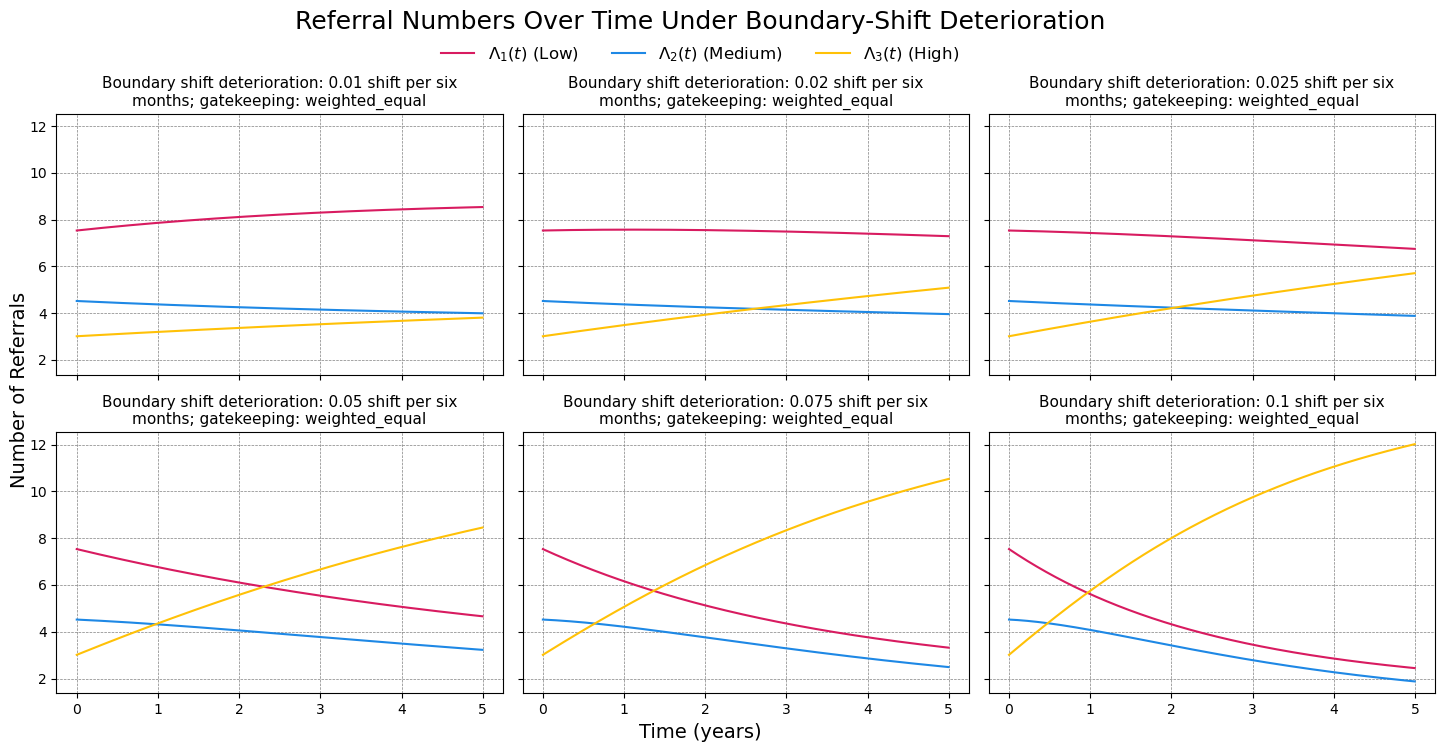

In [35]:
selected_scenarios = (
    scenario_metadata.loc[
        scenario_metadata["deterioration_model"]
        == "boundary_shift",
        "scenario",
    ]
    .tolist()
)

filename = (
    plot_dir
    / "boundary_shift_referral_numbers.pdf"
)

fig, axes = plot_referral_numbers_over_time_grid(
    selected_scenarios=selected_scenarios,
    scenario_lookup=scenario_lookup,
    stocks_array=stocks_array,
    lambdas_array=lambdas_array,
    scenario_metadata=scenario_metadata,
    t=t,
    ncols=3,
    nrows=2,
    figsize=(15, 8),
    subtitle_width=50,
    ylim=None,
    title=(
        "Referral Numbers Over Time Under "
        "Boundary-Shift Deterioration"
    ),
    filename=filename,
    show=True,
)

### Plot Stock Proportional Deterioration Results

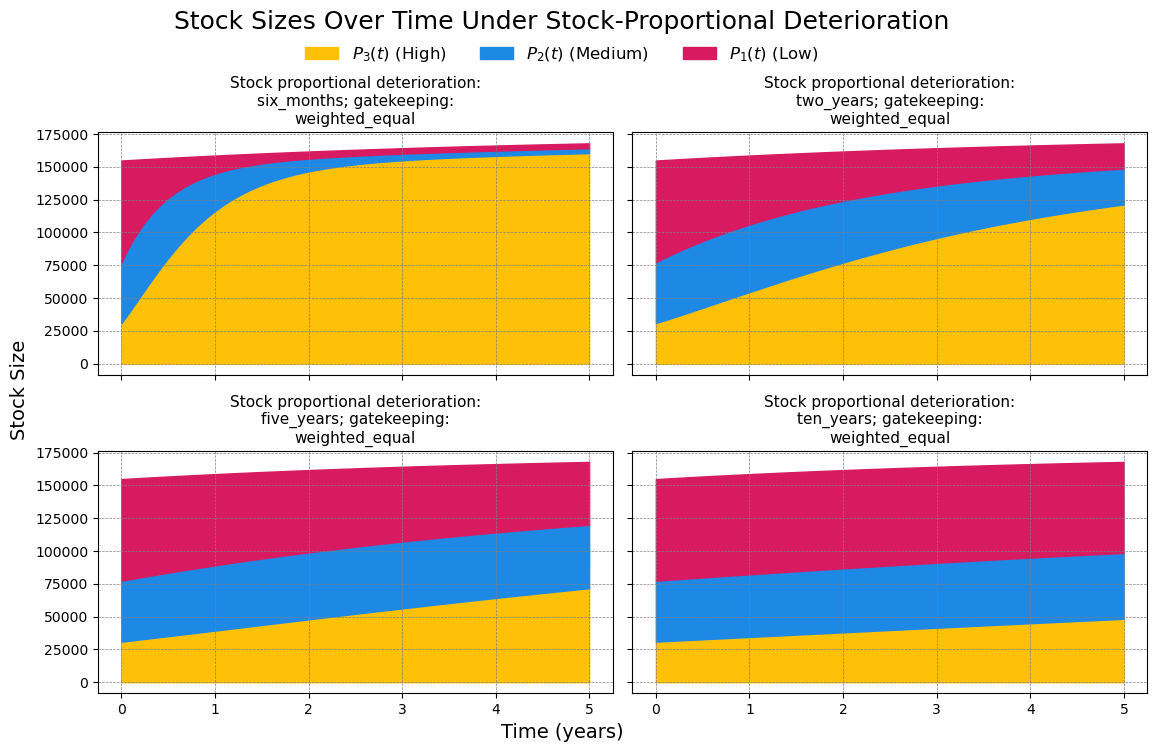

In [36]:
selected_scenarios = (
    scenario_metadata.loc[
        scenario_metadata["deterioration_model"]
        == "stock_proportional",
        "scenario",
    ]
    .tolist()
)

filename = (
    plot_dir
    / "stock_proportional_stocks.pdf"
)

fig, axes = plot_stacked_stocks_over_time_grid(
    selected_scenarios=selected_scenarios,
    stocks_array=stocks_array,
    lambdas_array=lambdas_array,
    scenario_metadata=scenario_metadata,
    t=t,
    nrows=2,
    ncols=2,
    figsize=(12, 8),
    title=(
        "Stock Sizes Over Time Under "
        "Stock-Proportional Deterioration"
    ),
    filename=filename,
    show=True,
)

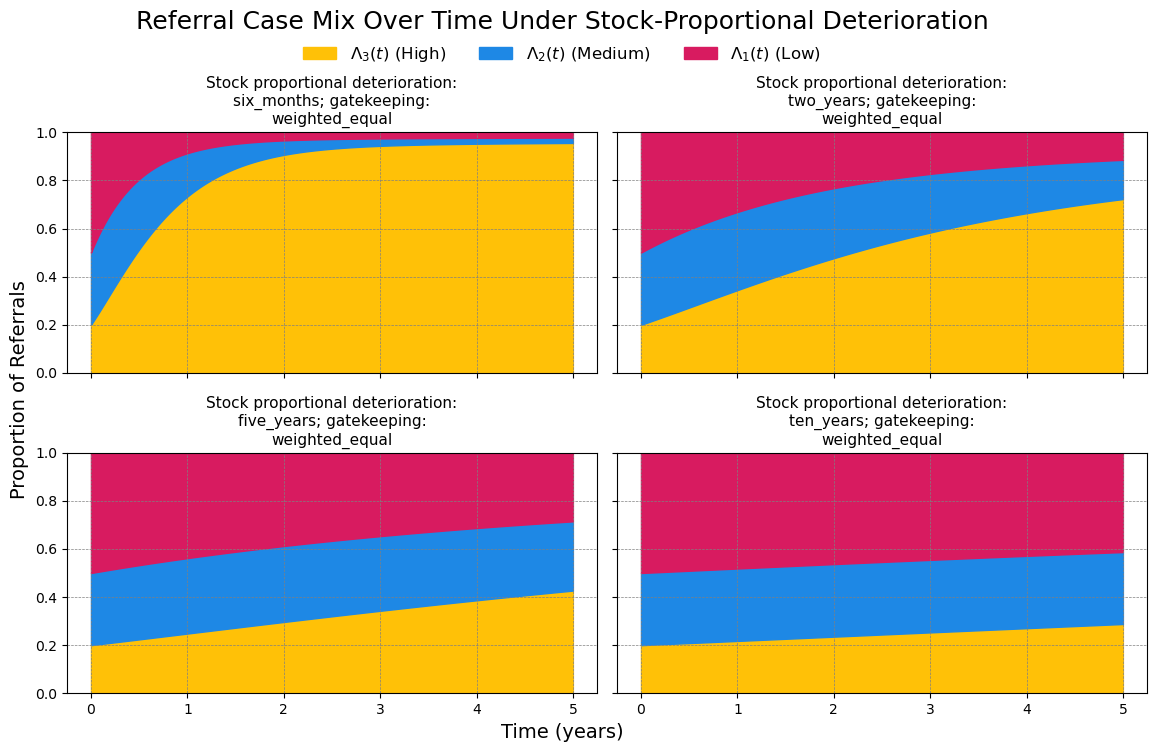

In [37]:
selected_scenarios = (
    scenario_metadata.loc[
        scenario_metadata["deterioration_model"]
        == "stock_proportional",
        "scenario",
    ]
    .tolist()
)

filename = (
    plot_dir
    / "stock_proportional_referral_case_mix.pdf"
)

fig, axes = plot_referral_case_mix_over_time_grid(
    selected_scenarios=selected_scenarios,
    scenario_lookup=scenario_lookup,
    stocks_array=stocks_array,
    lambdas_array=lambdas_array,
    scenario_metadata=scenario_metadata,
    t=t,
    nrows=2,
    ncols=2,
    figsize=(12, 8),
    title=(
        "Referral Case Mix Over Time Under "
        "Stock-Proportional Deterioration"
    ),
    filename=filename,
    show=True,
)

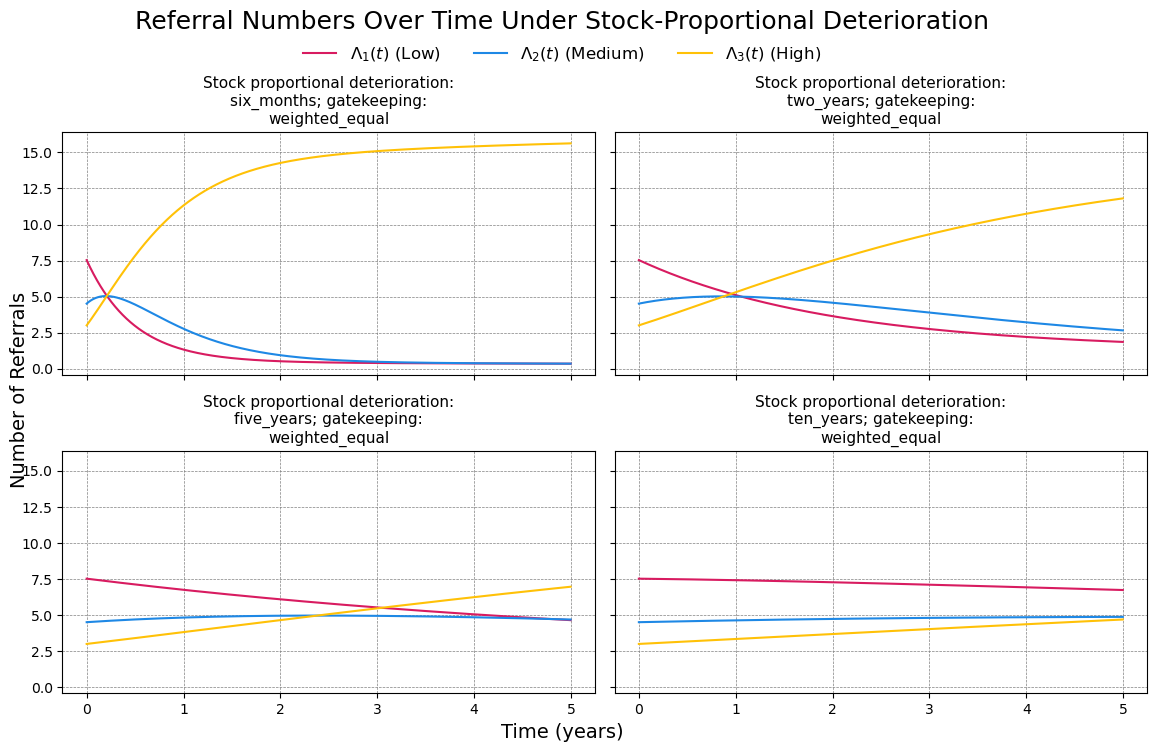

In [38]:
selected_scenarios = (
    scenario_metadata.loc[
        scenario_metadata["deterioration_model"]
        == "stock_proportional",
        "scenario",
    ]
    .tolist()
)

filename = (
    plot_dir
    / "stock_proportional_referral_numbers.pdf"
)

fig, axes = plot_referral_numbers_over_time_grid(
    selected_scenarios=selected_scenarios,
    scenario_lookup=scenario_lookup,
    stocks_array=stocks_array,
    lambdas_array=lambdas_array,
    scenario_metadata=scenario_metadata,
    t=t,
    figsize=(12, 8),
    ylim=None,
    title=(
        "Referral Numbers Over Time Under "
        "Stock-Proportional Deterioration"
    ),
    filename=filename,
    show=True,
)